# IoT Telemetry Ingestion and Initial Exploration

## Objective

The goal of this notebook is to ingest the AI4I Predictive Maintenance Dataset and perform an initial exploration of the telemetry data.

Tasks:
- Load dataset
- Verify schema
- Check data quality
- Analyze target distribution
- Generate summary statistics

In [2]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("../data/raw/ai4i2020.csv")

print(df.shape)
df.head()

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [5]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [6]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [7]:
failure_counts = df["Machine failure"].value_counts()

print(failure_counts)

failure_rate = df["Machine failure"].mean() * 100

print(f"Failure Rate: {failure_rate:.2f}%")

Machine failure
0    9661
1     339
Name: count, dtype: int64
Failure Rate: 3.39%


In [8]:
df.dtypes

UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

## Data Quality Assessment

Before feature engineering, the dataset is assessed for:

- Missing values
- Duplicate records
- Class imbalance
- Data types
- Numerical feature distributions

In [9]:
duplicates = df.duplicated().sum()

print(f"Duplicate Records: {duplicates}")

Duplicate Records: 0


In [10]:
missing_summary = pd.DataFrame(
    {
        "Missing Values": df.isnull().sum(),
        "Percentage": (df.isnull().sum() / len(df)) * 100,
    }
)

missing_summary

,Missing Values,Percentage
UDI,0,0.0
Product ID,0,0.0
Type,0,0.0
Air temperature [K],0,0.0
Process temperature [K],0,0.0
Rotational speed [rpm],0,0.0
Torque [Nm],0,0.0
Tool wear [min],0,0.0
Machine failure,0,0.0
TWF,0,0.0


In [11]:
failure_counts = df["Machine failure"].value_counts()

failure_percentages = df["Machine failure"].value_counts(normalize=True) * 100

imbalance_df = pd.DataFrame(
    {"Count": failure_counts, "Percentage": failure_percentages}
)

imbalance_df

,Count,Percentage
Machine failure,,
0,9661,96.61
1,339,3.39


In [12]:
import matplotlib.pyplot as plt

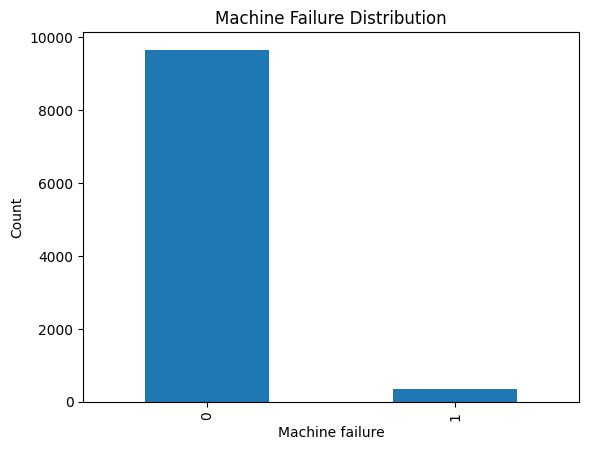

In [13]:
failure_counts.plot(kind="bar")

plt.title("Machine Failure Distribution")

plt.ylabel("Count")

plt.show()

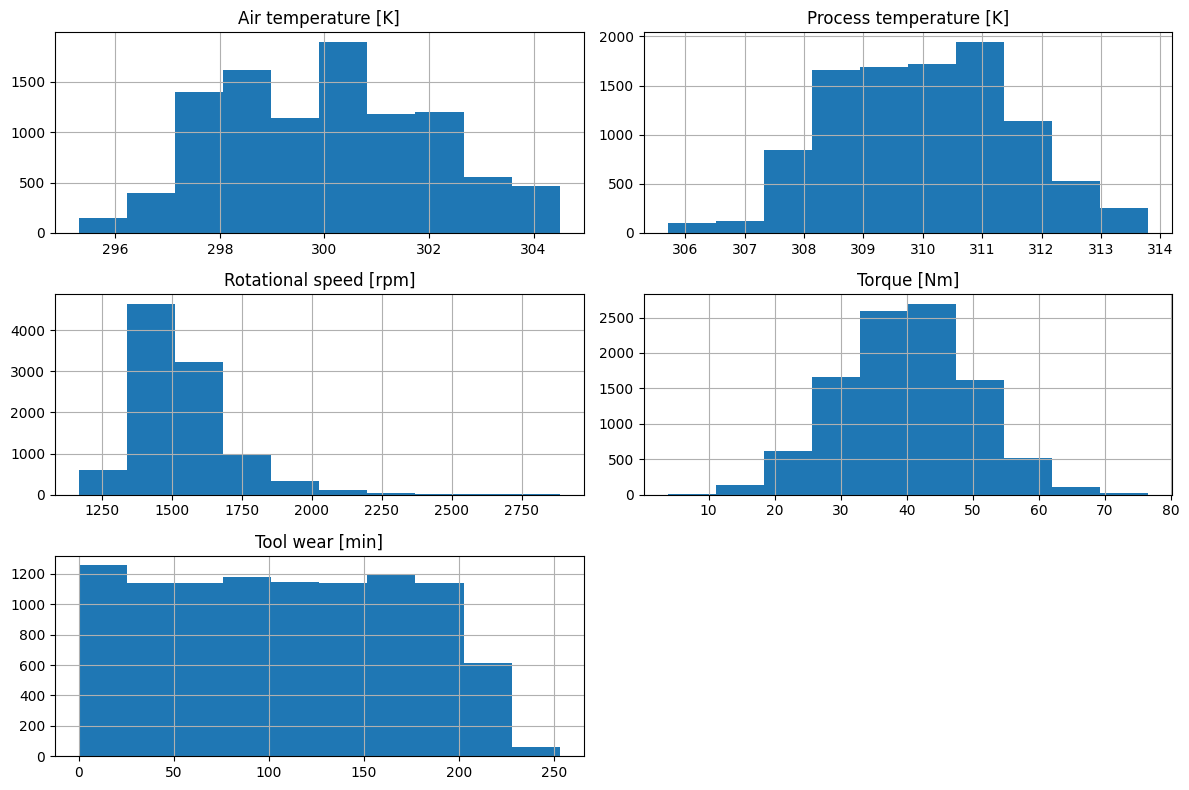

In [14]:
numerical_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

df[numerical_cols].hist(figsize=(12, 8))

plt.tight_layout()

plt.show()

In [15]:
feature_ranges = pd.DataFrame(
    {
        "Min": df[numerical_cols].min(),
        "Max": df[numerical_cols].max(),
        "Mean": df[numerical_cols].mean(),
    }
)

feature_ranges

,Min,Max,Mean
Air temperature [K],295.3,304.5,300.00493
Process temperature [K],305.7,313.8,310.00556
Rotational speed [rpm],1168.0,2886.0,1538.77610
Torque [Nm],3.8,76.6,39.98691
Tool wear [min],0.0,253.0,107.95100


### Findings

- No missing values were detected.
- No duplicate records were found.
- Machine failures represent approximately 3.39% of observations.
- The dataset is highly imbalanced and will require specialized handling during modeling.